In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

In [2]:
df = pd.read_csv("/content/Students suspicious behaviors detection dataset_V1.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (5500, 38)
   face_present  no_of_face      face_x      face_y      face_w      face_h  \
0             1           1  262.579536  312.062903  151.787758  151.787567   
1             1           1  260.704193  312.342424  154.607773  154.607735   
2             1           1  264.240570  311.801834  148.079300  148.079195   
3             1           1  262.811012  314.088278  151.014061  151.014175   
4             1           1  269.176426  312.678709  148.739681  148.739605   

   left_eye_x  left_eye_y  right_eye_x  right_eye_y  ...  phone_conf  \
0  307.918568  354.478884   373.059845   353.494949  ...         0.0   
1  305.797863  354.197273   372.084160   357.747831  ...         0.0   
2  304.438133  351.268072   368.618050   353.264036  ...         0.0   
3  304.091930  355.737219   369.532318   355.841103  ...         0.0   
4  310.720120  354.326448   374.389267   350.510445  ...         0.0   

   gaze_on_script  gaze_direction  gazePoint_x  gazePoint_y  pupil_left_x 

In [3]:
print("\nNull values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Null values:
head_pose          569
gaze_direction    1051
dtype: int64


In [4]:
df['head_pose']      = df['head_pose'].fillna('unknown')
df['gaze_direction'] = df['gaze_direction'].fillna('unknown')

In [5]:
le = LabelEncoder()
df['head_pose']      = le.fit_transform(df['head_pose'])
df['gaze_direction'] = le.fit_transform(df['gaze_direction'])

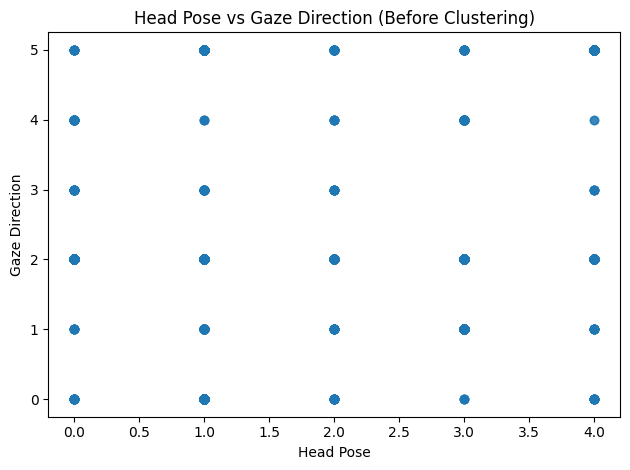

In [6]:
plt.scatter(df['head_pose'], df['gaze_direction'], alpha=0.5)
plt.xlabel('Head Pose')
plt.ylabel('Gaze Direction')
plt.title('Head Pose vs Gaze Direction (Before Clustering)')
plt.tight_layout()
plt.show()

In [7]:
km = KMeans(n_clusters=3, random_state=42)
y_predicted = km.fit_predict(df[['head_pose', 'gaze_direction']])
y_predicted

array([0, 0, 0, ..., 0, 1, 1], dtype=int32)

In [8]:
df['cluster'] = y_predicted
print(df.head())

   face_present  no_of_face      face_x      face_y      face_w      face_h  \
0             1           1  262.579536  312.062903  151.787758  151.787567   
1             1           1  260.704193  312.342424  154.607773  154.607735   
2             1           1  264.240570  311.801834  148.079300  148.079195   
3             1           1  262.811012  314.088278  151.014061  151.014175   
4             1           1  269.176426  312.678709  148.739681  148.739605   

   left_eye_x  left_eye_y  right_eye_x  right_eye_y  ...  gaze_on_script  \
0  307.918568  354.478884   373.059845   353.494949  ...               1   
1  305.797863  354.197273   372.084160   357.747831  ...               1   
2  304.438133  351.268072   368.618050   353.264036  ...               1   
3  304.091930  355.737219   369.532318   355.841103  ...               1   
4  310.720120  354.326448   374.389267   350.510445  ...               1   

   gaze_direction  gazePoint_x  gazePoint_y  pupil_left_x  pupil_lef

In [9]:
print("\nCluster Centers:")
print(km.cluster_centers_)


Cluster Centers:
[[0.94701646 1.85416667]
 [2.30912312 4.93091231]
 [3.27122153 1.48033126]]


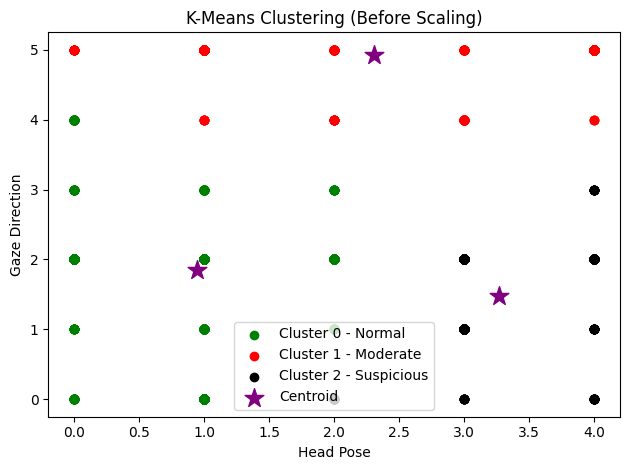

In [10]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

plt.scatter(df1['head_pose'], df1['gaze_direction'], color='green', label='Cluster 0 - Normal')
plt.scatter(df2['head_pose'], df2['gaze_direction'], color='red',   label='Cluster 1 - Moderate')
plt.scatter(df3['head_pose'], df3['gaze_direction'], color='black', label='Cluster 2 - Suspicious')
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            color='purple', marker='*', s=200, label='Centroid')
plt.xlabel('Head Pose')
plt.ylabel('Gaze Direction')
plt.title('K-Means Clustering (Before Scaling)')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
scaler = MinMaxScaler()

scaler.fit(df[['head_pose']])
df['head_pose'] = scaler.transform(df[['head_pose']])

scaler.fit(df[['gaze_direction']])
df['gaze_direction'] = scaler.transform(df[['gaze_direction']])

print(df.head())

   face_present  no_of_face      face_x      face_y      face_w      face_h  \
0             1           1  262.579536  312.062903  151.787758  151.787567   
1             1           1  260.704193  312.342424  154.607773  154.607735   
2             1           1  264.240570  311.801834  148.079300  148.079195   
3             1           1  262.811012  314.088278  151.014061  151.014175   
4             1           1  269.176426  312.678709  148.739681  148.739605   

   left_eye_x  left_eye_y  right_eye_x  right_eye_y  ...  gaze_on_script  \
0  307.918568  354.478884   373.059845   353.494949  ...               1   
1  305.797863  354.197273   372.084160   357.747831  ...               1   
2  304.438133  351.268072   368.618050   353.264036  ...               1   
3  304.091930  355.737219   369.532318   355.841103  ...               1   
4  310.720120  354.326448   374.389267   350.510445  ...               1   

   gaze_direction  gazePoint_x  gazePoint_y  pupil_left_x  pupil_lef

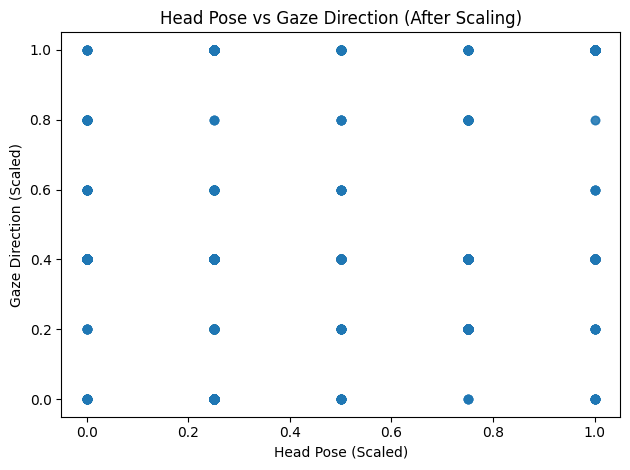

In [12]:
plt.scatter(df['head_pose'], df['gaze_direction'], alpha=0.5)
plt.xlabel('Head Pose (Scaled)')
plt.ylabel('Gaze Direction (Scaled)')
plt.title('Head Pose vs Gaze Direction (After Scaling)')
plt.tight_layout()
plt.show()

In [13]:
km = KMeans(n_clusters=3, random_state=42)
y_predicted = km.fit_predict(df[['head_pose', 'gaze_direction']])
y_predicted

array([0, 0, 0, ..., 0, 1, 1], dtype=int32)

In [14]:
df['cluster'] = y_predicted
print(df.head())

   face_present  no_of_face      face_x      face_y      face_w      face_h  \
0             1           1  262.579536  312.062903  151.787758  151.787567   
1             1           1  260.704193  312.342424  154.607773  154.607735   
2             1           1  264.240570  311.801834  148.079300  148.079195   
3             1           1  262.811012  314.088278  151.014061  151.014175   
4             1           1  269.176426  312.678709  148.739681  148.739605   

   left_eye_x  left_eye_y  right_eye_x  right_eye_y  ...  gaze_on_script  \
0  307.918568  354.478884   373.059845   353.494949  ...               1   
1  305.797863  354.197273   372.084160   357.747831  ...               1   
2  304.438133  351.268072   368.618050   353.264036  ...               1   
3  304.091930  355.737219   369.532318   355.841103  ...               1   
4  310.720120  354.326448   374.389267   350.510445  ...               1   

   gaze_direction  gazePoint_x  gazePoint_y  pupil_left_x  pupil_lef

In [15]:
print("\nCluster Centers (Scaled):")
print(km.cluster_centers_)


Cluster Centers (Scaled):
[[0.23830222 0.36865252]
 [0.57728078 0.98618246]
 [0.83369565 0.31086957]]


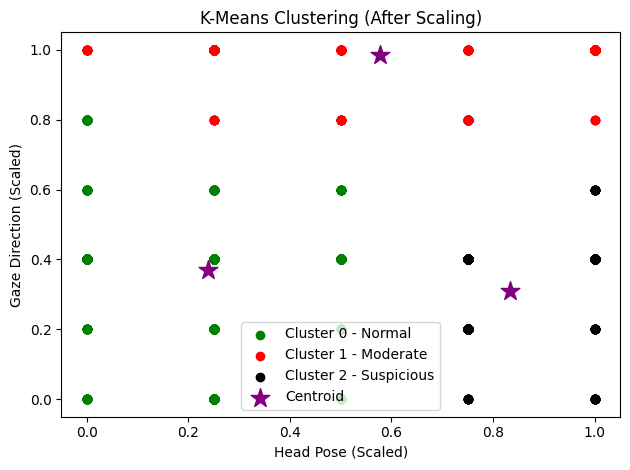

In [16]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

plt.scatter(df1['head_pose'], df1['gaze_direction'], color='green', label='Cluster 0 - Normal')
plt.scatter(df2['head_pose'], df2['gaze_direction'], color='red',   label='Cluster 1 - Moderate')
plt.scatter(df3['head_pose'], df3['gaze_direction'], color='black', label='Cluster 2 - Suspicious')
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            color='purple', marker='*', s=200, label='Centroid')
plt.xlabel('Head Pose (Scaled)')
plt.ylabel('Gaze Direction (Scaled)')
plt.title('K-Means Clustering (After Scaling)')
plt.legend()
plt.tight_layout()
plt.show()

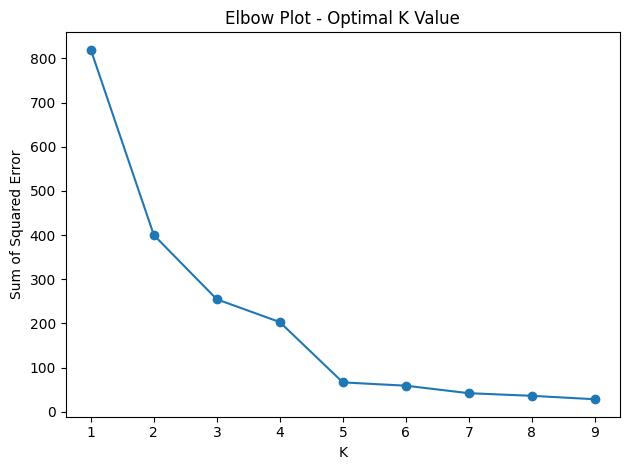

In [17]:
sse   = []
k_rng = range(1, 10)

for k in k_rng:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df[['head_pose', 'gaze_direction']])
    sse.append(km.inertia_)

plt.xlabel('K')
plt.ylabel('Sum of Squared Error')
plt.title('Elbow Plot - Optimal K Value')
plt.plot(k_rng, sse, marker='o')
plt.tight_layout()
plt.show()